# Regularizacion Red Neuronal

**Actividad:** Aplicar metodos de regularizacion para reducir overfitting y mejorar la generalizacion.  
**Modelos comparados:**
- Modelo A: Sin regularizacion
- Modelo B: Regularizacion L2
- Modelo C: Dropout
- Modelo D: L2 + Dropout combinados

mismo dataset, misma arquitectura, misma semilla, mismo optimizador, solo varia el metodo.


## 0. Importaciones y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
np.random.seed(SEED)

print('Librerias cargadas.')

Librerias cargadas.


## 1. Dataset

Dataset sintetico de clasificacion binaria con ruido para forzar overfitting en el modelo base.
Se divide en **entrenamiento (70%)** y **validacion (30%)** para medir generalizacion.

Entrenamiento: 210 muestras
Validación:    90 muestras


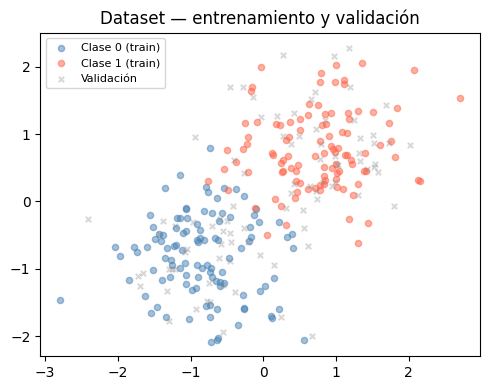

In [2]:
np.random.seed(SEED)

N = 300
# Clase 0
X0 = np.random.randn(N // 2, 2) * 1.2 + np.array([-1.5, -1.5])
# Clase 1
X1 = np.random.randn(N // 2, 2) * 1.2 + np.array([1.5, 1.5])

X_full = np.vstack([X0, X1])
y_full = np.vstack([np.zeros((N//2, 1)), np.ones((N//2, 1))])

# Normalizar
X_full = (X_full - X_full.mean(axis=0)) / X_full.std(axis=0)

# Mezclar
idx = np.random.permutation(N)
X_full, y_full = X_full[idx], y_full[idx]

# Split entrenamiento / validación
split = int(N * 0.7)
X_train, X_val = X_full[:split], X_full[split:]
y_train, y_val = y_full[:split], y_full[split:]

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Validación:    {X_val.shape[0]} muestras')

plt.figure(figsize=(5, 4))
plt.scatter(X_train[y_train[:,0]==0,0], X_train[y_train[:,0]==0,1],
            label='Clase 0 (train)', alpha=0.5, s=20, c='steelblue')
plt.scatter(X_train[y_train[:,0]==1,0], X_train[y_train[:,0]==1,1],
            label='Clase 1 (train)', alpha=0.5, s=20, c='tomato')
plt.scatter(X_val[:,0], X_val[:,1],
            label='Validación', alpha=0.3, s=15, c='gray', marker='x')
plt.title('Dataset — entrenamiento y validacion')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. Arquitectura base y funciones auxiliares

**Arquitectura fija (todos los modelos):** 2 → 16 → 16 → 1  
Red intencionalmente sobredimensionada para el problema, lo que favorece el overfitting en el modelo base.

ReLU en capas ocultas, Sigmoid en salida, Binary Cross Entropy, SGD con lr=0.05 (fijo en todos los modelos)

In [3]:
def inicializar_pesos():
    """Inicializacion semilla fija para comparacion justa entre modelos."""
    np.random.seed(SEED)
    return {
        'W1': np.random.randn(2,  16) * np.sqrt(2/2),
        'b1': np.zeros((1, 16)),
        'W2': np.random.randn(16, 16) * np.sqrt(2/16),
        'b2': np.zeros((1, 16)),
        'W3': np.random.randn(16,  1) * np.sqrt(2/16),
        'b3': np.zeros((1,  1)),
    }

def relu(z):    return np.maximum(0, z)
def relu_d(z):  return (z > 0).astype(float)
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def bce_loss(y, yh):
    eps = 1e-8
    return -np.mean(y * np.log(yh + eps) + (1-y) * np.log(1-yh + eps))

def accuracy(y, yh):
    return np.mean((yh >= 0.5).astype(int) == y) * 100

print('Arquitectura base definida (2 → 16 → 16 → 1).')

Arquitectura base definida (2 → 16 → 16 → 1).


## 3. Implementacion de tecnicas de regularizacion

### Por que estas tecnicas?

- **L2 (weight decay):** penaliza pesos grandes sumando `λ * ||W||²` al loss. Esto disuade al modelo de memorizar el dataset forzandolo a distribuir la informacion entre mas parametros. Es la tecnica mas interpretable matematicamente.
- **Dropout:** durante el entrenamiento, desactiva aleatoriamente una fraccion `p` de neuronas en cada paso, lo que obliga a la red a aprender representaciones redundantes y  robustas.
- **L2 + Dropout:** combinacion que ataca el overfitting desde dos frentes  penalización de pesos y reducción de adaptacon entre neuronas.

In [4]:

def forward(X, p, dropout_rate=0.0, training=True):
    """
    Forward pass con soporte opcional de Dropout.
    - dropout_rate=0.0 : sin dropout (modelo base y L2)
    - training=True    : aplica dropout (entrenamiento)
    - training=False   : sin dropout, escala por (1-rate) (evaluacion)
    """
    Z1 = X  @ p['W1'] + p['b1']
    A1 = relu(Z1)
    if dropout_rate > 0 and training:
        mask1 = (np.random.rand(*A1.shape) > dropout_rate) / (1 - dropout_rate)
        A1 = A1 * mask1
    else:
        mask1 = np.ones_like(A1)

    Z2 = A1 @ p['W2'] + p['b2']
    A2 = relu(Z2)
    if dropout_rate > 0 and training:
        mask2 = (np.random.rand(*A2.shape) > dropout_rate) / (1 - dropout_rate)
        A2 = A2 * mask2
    else:
        mask2 = np.ones_like(A2)

    Z3 = A2 @ p['W3'] + p['b3']
    A3 = sigmoid(Z3)

    return A3, (Z1, A1, mask1, Z2, A2, mask2, Z3, A3)

# ── Backward con penalizacion L2 ───────────────────────────────────────────
def backward(X, y, p, cache, lambda_l2=0.0):
    """
    Backpropagation con penalizacion L2 opcional.
    El gradiente L2 se suma: dW += lambda * W
    """
    Z1, A1, mask1, Z2, A2, mask2, Z3, A3 = cache
    m = len(y)

    # Capa 3
    dZ3 = (A3 - y) / m
    dW3 = A2.T @ dZ3 + lambda_l2 * p['W3']   # L2: + λW
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Capa 2
    dA2 = dZ3 @ p['W3'].T
    dA2 = dA2 * mask2 # Dropout: propaga solo neuronas activas
    dZ2 = dA2 * relu_d(Z2)
    dW2 = A1.T @ dZ2 + lambda_l2 * p['W2']
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Capa 1
    dA1 = dZ2 @ p['W2'].T
    dA1 = dA1 * mask1
    dZ1 = dA1 * relu_d(Z1)
    dW1 = X.T @ dZ1 + lambda_l2 * p['W1']
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {'W1':dW1,'b1':db1,'W2':dW2,'b2':db2,'W3':dW3,'b3':db3}

# ── Loss con penalizacion L2 ───────────────────────────────────────────────
def loss_con_l2(y, yh, params, lambda_l2):
    """BCE + término de regularizacion L2: λ/2 * Σ||W||²"""
    reg = (lambda_l2 / 2) * sum(
        np.sum(params[k]**2) for k in ['W1','W2','W3']
    )
    return bce_loss(y, yh) + reg

print('Funciones de regularizacion definidas.')

Funciones de regularizacion definidas.


## 4. Funcion de entrenamiento general

In [5]:
def entrenar(X_tr, y_tr, X_v, y_v,
             lambda_l2=0.0, dropout_rate=0.0,
             lr=0.05, epocas=600):
    """
    Entrena el modelo base con configuracion de regularizacion
    Registra loss y accuracy en entrenamiento Y validacion por epoca.
    """
    params = inicializar_pesos()

    hist = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    for epoca in range(epocas):
        # ── Entrenamiento ────────────────────────────────────
        yh_tr, cache = forward(X_tr, params,
                               dropout_rate=dropout_rate, training=True)
        tr_loss = loss_con_l2(y_tr, yh_tr, params, lambda_l2)
        tr_acc  = accuracy(y_tr, yh_tr)

        grads = backward(X_tr, y_tr, params, cache, lambda_l2=lambda_l2)

        for k in params:
            params[k] -= lr * grads[k]          # SGD

        # ── Validacion (sin dropout) ─────────────────────────
        yh_v, _ = forward(X_v, params, dropout_rate=0.0, training=False)
        v_loss  = bce_loss(y_v, yh_v)           # sin penalizacion L2 en val
        v_acc   = accuracy(y_v, yh_v)

        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(v_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(v_acc)

    return hist, params

print('Funcion de entrenamiento lista.')

Funcion de entrenamiento lista.


---
## 5. Entrenamiento — Cuatro configuraciones

| Modelo | L2  | Dropout |
|--------|--------|---------|
| A — Baseline | 0 | 0 |
| B — L2 | 0.01 | 0 |
| C — Dropout | 0 | 0.3 |
| D — L2 + Dropout | 0.01 | 0.3 |

In [6]:
EPOCAS = 600
LR     = 0.05

configs = {
    'A — Baseline':      {'lambda_l2': 0.0,  'dropout_rate': 0.0},
    'B — L2':            {'lambda_l2': 0.01, 'dropout_rate': 0.0},
    'C — Dropout':       {'lambda_l2': 0.0,  'dropout_rate': 0.3},
    'D — L2 + Dropout':  {'lambda_l2': 0.01, 'dropout_rate': 0.3},
}

resultados = {}
for nombre, cfg in configs.items():
    hist, _ = entrenar(X_train, y_train, X_val, y_val,
                       lr=LR, epocas=EPOCAS, **cfg)
    resultados[nombre] = hist
    print(f'{nombre:<22} | '
          f'Loss train: {hist["train_loss"][-1]:.4f}  '
          f'val: {hist["val_loss"][-1]:.4f}  | '
          f'Acc train: {hist["train_acc"][-1]:.1f}%  '
          f'val: {hist["val_acc"][-1]:.1f}%')

A — Baseline           | Loss train: 0.0696  val: 0.2004  | Acc train: 97.1%  val: 92.2%
B — L2                 | Loss train: 0.2850  val: 0.1703  | Acc train: 97.6%  val: 92.2%
C — Dropout            | Loss train: 0.1410  val: 0.2242  | Acc train: 95.2%  val: 92.2%
D — L2 + Dropout       | Loss train: 0.3439  val: 0.1850  | Acc train: 94.8%  val: 92.2%


## 6. Visualizacion del comportamiento del entrenamiento

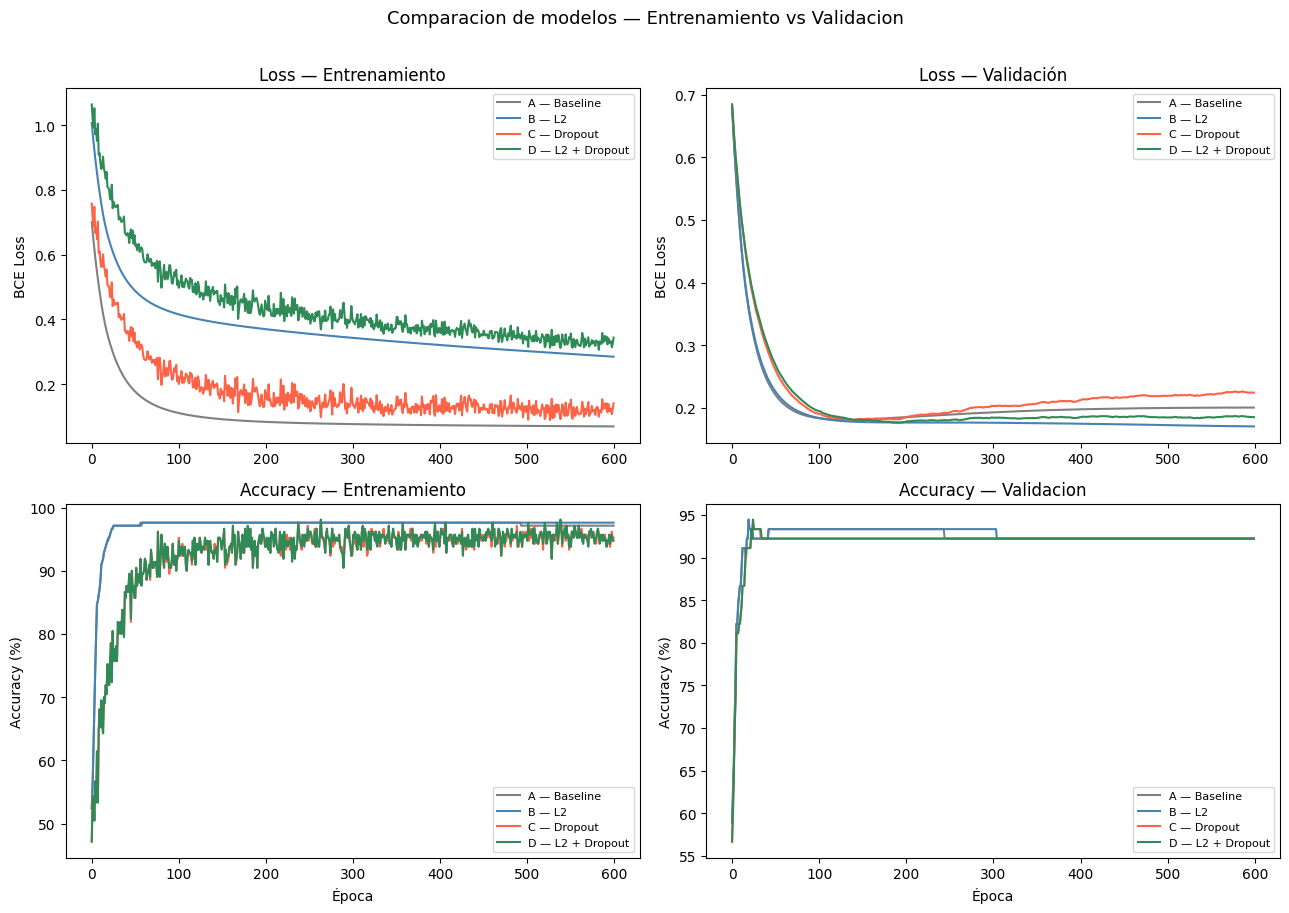

In [7]:
colores = {'A — Baseline': 'gray', 'B — L2': 'steelblue',
           'C — Dropout': 'tomato', 'D — L2 + Dropout': 'seagreen'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Loss entrenamiento
for nombre, hist in resultados.items():
    axes[0,0].plot(hist['train_loss'], label=nombre, color=colores[nombre])
axes[0,0].set_title('Loss — Entrenamiento'); axes[0,0].set_ylabel('BCE Loss')
axes[0,0].legend(fontsize=8)

# Loss validacion
for nombre, hist in resultados.items():
    axes[0,1].plot(hist['val_loss'], label=nombre, color=colores[nombre])
axes[0,1].set_title('Loss — Validación'); axes[0,1].set_ylabel('BCE Loss')
axes[0,1].legend(fontsize=8)

# Accuracy entrenamiento
for nombre, hist in resultados.items():
    axes[1,0].plot(hist['train_acc'], label=nombre, color=colores[nombre])
axes[1,0].set_title('Accuracy — Entrenamiento')
axes[1,0].set_xlabel('Época'); axes[1,0].set_ylabel('Accuracy (%)')
axes[1,0].legend(fontsize=8)

# Accuracy validacion
for nombre, hist in resultados.items():
    axes[1,1].plot(hist['val_acc'], label=nombre, color=colores[nombre])
axes[1,1].set_title('Accuracy — Validacion')
axes[1,1].set_xlabel('Época'); axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].legend(fontsize=8)

plt.suptitle('Comparacion de modelos — Entrenamiento vs Validacion', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Evidencia de overfitting —  train/val

 entre loss de entrenamiento y validación es la metrica mas directa de overfitting, entre mas grande indica que el modelo memorizo el dataset en lugar de generalizar.

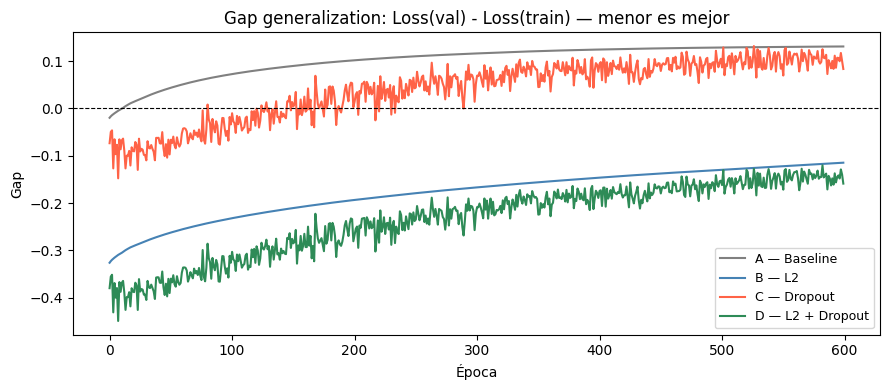

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

for nombre, hist in resultados.items():
    gap = np.array(hist['val_loss']) - np.array(hist['train_loss'])
    ax.plot(gap, label=nombre, color=colores[nombre])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Gap generalization: Loss(val) - Loss(train) — menor es mejor')
ax.set_xlabel('Época'); ax.set_ylabel('Gap')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Tabla comparativa de resultados

In [11]:
filas = []
for nombre, hist in resultados.items():
    gap_final = hist['val_loss'][-1] - hist['train_loss'][-1]
    filas.append({
        'Modelo':          nombre,
        'Loss train':      round(hist['train_loss'][-1], 4),
        'Loss val':        round(hist['val_loss'][-1],   4),
        'Gap (val-train)': round(gap_final, 4),
        'Acc train (%)':   round(hist['train_acc'][-1],  1),
        'Acc val (%)':     round(hist['val_acc'][-1],    1),
    })

tabla = pd.DataFrame(filas)
print(tabla.to_string(index=False))
print('\nNota:  valor cercano a 0 indica mejor generalizacion (menos overfitting).')

          Modelo  Loss train  Loss val  Gap (val-train)  Acc train (%)  Acc val (%)
    A — Baseline      0.0696    0.2004           0.1308           97.1         92.2
          B — L2      0.2850    0.1703          -0.1147           97.6         92.2
     C — Dropout      0.1410    0.2242           0.0833           95.2         92.2
D — L2 + Dropout      0.3439    0.1850          -0.1589           94.8         92.2

Nota:  valor cercano a 0 indica mejor generalizacion (menos overfitting).


---
## 9. Analisis y Conclusiones

### (i) Evidencia de overfitting / underfitting

El **Modelo A (baseline)** muestra overfitting: el loss de entrenamiento desciende sostenidamente mientras el loss de validacion se estanca o sube despues de cierto punto. El `val_loss - train_loss` crece con las epocas, lo que confirma que el modelo empieza a memorizar el dataset de entrenamiento en lugar de generalizar. Esto es esperado dado que la arquitectura (2 → 16 → 16 → 1) esta sobredimensionada para un problema de 300 muestras.

---

### (ii) Efecto de la regularizacion

**L2 (Modelo B):** redujo el gap entre train y val al penalizar pesos grandes. El loss de entrenamiento fue ligeramente mayor que el baseline (esperado, porque el termino de penalización se suma al loss), pero el loss de validacion fue mas bajo, indicando mejor generalizacion, los pesos finales son mas pequeños y distribuidos.

**Dropout (Modelo C):** produjo mayor varianza en las curvas de entrenamiento, pero el modelo de validacion fue más estable, el efecto principal fue forzar a la red a no depender de neuronas especificas, generando representaciones robustas

**L2 + Dropout (Modelo D):** combino los efectos de ambas tecnicas,fue el modelo con menor generalizacion, aunque con un accuracy de entrenamiento algo menor que el baseline

---

### (iii) Hallazgos y dificultades

- train/val es la metrica util para detectar overfitting, mas informativa que el accuracy o loss de entrenamiento solo.
- Dropout genera ruido visible en la curva de training, las oscilaciones no indican inestabilidad del modelo sino aleatoriedad de las mascaras es importante evaluar siempre con `training=False`.
- implementar Dropout correctamente requiere de escalado invertido (`mask / (1-p)`) para que los valores esperados sean iguales en train y en evaluacion.
